In [3]:
# ============================================
# Week 3 — Function 01 Bayesian Optimisation
# Retrain surrogate + uncertainty + acquisition
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, qmc

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [4]:
# ----------------------------
# 0) CONFIG F1
# ----------------------------
INPUTS_PATH = "data/F1/initial_inputs.npy"
OUTPUTS_PATH = "data/F1/initial_outputs.npy"

BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
])

MAXIMIZE = True        # set False if minimizing
XI = 0.01              # EI exploration parameter (bigger -> more exploration)
N_CAND = 20000         # number of candidate points to score with EI
BATCH_SIZE = 2         # points to submit this week
MIN_DIST = 0.04        # min distance between batch points (diversity)
RANDOM_SEED = 0


In [5]:
# ----------------------------
# 1) LOAD DATA F1 - Arrays directly
# ----------------------------
X = np.load(INPUTS_PATH).astype(float)
y = np.load(OUTPUTS_PATH).astype(float).reshape(-1,)

if X.ndim != 2 or X.shape[1] != 2:
    raise ValueError(f"Expected X shape (n,2). Got {X.shape}")
if y.shape[0] != X.shape[0]:
    raise ValueError(f"X and y size mismatch: {X.shape[0]} vs {y.shape[0]}")

print("\nF1 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last values - input:", X[-1:], "output:", y[-1:])



F1 SHAPE - Inputs: (12, 2) Outputs: (12,)
Last values - input: [[0.6458 0.67  ]] output: [-0.00573427]


In [6]:
# ----------------------------
# 2) FIT SURROGATES
# ----------------------------
def fit_gp(X, y):
    # Matern GP with white noise; noise bounds widened to reduce convergence warnings
    kernel = (
        C(1.0, (1e-6, 1e6))
        * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-3, 1e5), nu=2.5)
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1.0))
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=RANDOM_SEED
    )
    gp.fit(X, y)
    return gp

def fit_rf(X, y):
    # IMPORTANT: max_features="auto" is invalid in newer sklearn.
    rf = RandomForestRegressor(
        n_estimators=600,
        min_samples_leaf=2,
        max_features=None,   # ✅ valid
        bootstrap=True,
        random_state=RANDOM_SEED,
        n_jobs=-1
    )
    rf.fit(X, y)
    return rf

def fit_gbm_ensemble(X, y, n_members=12):
    models = []
    for k in range(n_members):
        m = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=500,
            l2_regularization=1e-6,
            random_state=RANDOM_SEED + 100*k
        )
        m.fit(X, y)
        models.append(m)
    return models

gp = fit_gp(X, y)
rf = fit_rf(X, y)
gbm_ens = fit_gbm_ensemble(X, y, n_members=12)

print("\nGP kernel after fit:\n", gp.kernel_)



GP kernel after fit:
 0.799**2 * Matern(length_scale=[975, 0.0284], nu=2.5) + WhiteKernel(noise_level=0.167)


In [7]:
# ----------------------------
# 3) UNCERTAINTY ESTIMATION
# ----------------------------
def rf_mean_std(rf, Xcand):
    # tree-wise spread as uncertainty
    preds = np.vstack([t.predict(Xcand) for t in rf.estimators_])
    return preds.mean(axis=0), preds.std(axis=0, ddof=1)

def gbm_mean_std(models, Xcand):
    # ensemble spread as uncertainty
    preds = np.vstack([m.predict(Xcand) for m in models])
    return preds.mean(axis=0), preds.std(axis=0, ddof=1)

In [8]:
# ----------------------------
# 4) ACQUISITION: Expected Improvement (EI)
# ----------------------------
def expected_improvement(mu, sd, best, xi=0.01, maximize=True):
    sd = np.maximum(sd, 1e-12)
    imp = (mu - best - xi) if maximize else (best - mu - xi)
    Z = imp / sd
    ei = imp * norm.cdf(Z) + sd * norm.pdf(Z)
    return np.maximum(ei, 0.0)

In [10]:
# ----------------------------
# 5) CANDIDATE GENERATION (Sobol)
# ----------------------------

def sample_candidates(n=N_CAND, bounds=BOUNDS, seed=RANDOM_SEED):
    sampler = qmc.Sobol(d=bounds.shape[0], scramble=True, seed=seed)
    U = sampler.random(n)
    return qmc.scale(U, bounds[:, 0], bounds[:, 1])

Xcand = sample_candidates()

# surpress the sobol warning
def sample_candidates(n=N_CAND, bounds=BOUNDS, seed=RANDOM_SEED):
    sampler = qmc.Sobol(d=bounds.shape[0], scramble=True, seed=seed)
    m = int(np.floor(np.log2(n)))
    U = sampler.random_base2(m)   # generates 2^m points
    return qmc.scale(U, bounds[:, 0], bounds[:, 1])


In [11]:
# ----------------------------
# 6) SCORE ACQUISITION + PICK BATCH (diverse greedy)
# ----------------------------
mu_gp, sd_gp = gp.predict(Xcand, return_std=True)
best_y = float(np.max(y) if MAXIMIZE else np.min(y))
ei = expected_improvement(mu_gp, sd_gp, best_y, xi=XI, maximize=MAXIMIZE)

def pick_diverse_batch(Xcand, score, k=BATCH_SIZE, min_dist=MIN_DIST):
    order = np.argsort(score)[::-1]
    chosen = []
    for idx in order:
        if not chosen:
            chosen.append(idx)
        else:
            x = Xcand[idx]
            d = np.min([np.linalg.norm(x - Xcand[j]) for j in chosen])
            if d >= min_dist:
                chosen.append(idx)
        if len(chosen) == k:
            break
    return chosen

batch_idx = pick_diverse_batch(Xcand, ei, k=BATCH_SIZE, min_dist=MIN_DIST)
X_next = Xcand[batch_idx]

submit_df = pd.DataFrame(X_next, columns=["x1", "x2"]).round(6)
print("\n==============================")
print("=== SUBMIT THESE POINTS ===")
print("==============================")
display(submit_df)


=== SUBMIT THESE POINTS ===


,x1,x2
0,0.550173,0.334047
1,0.971901,0.334000


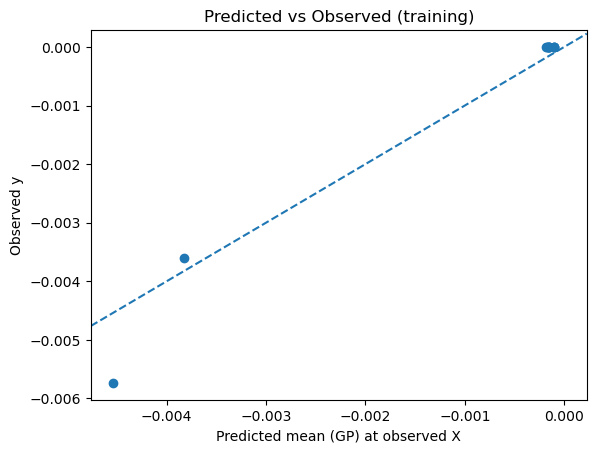

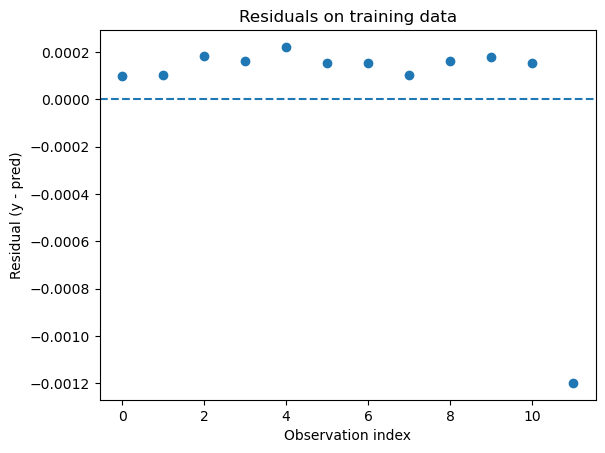

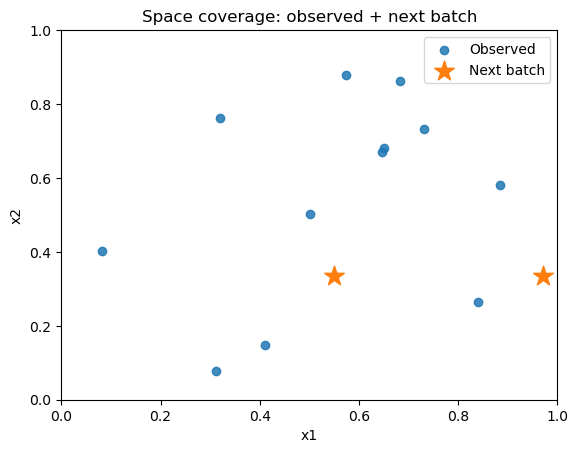

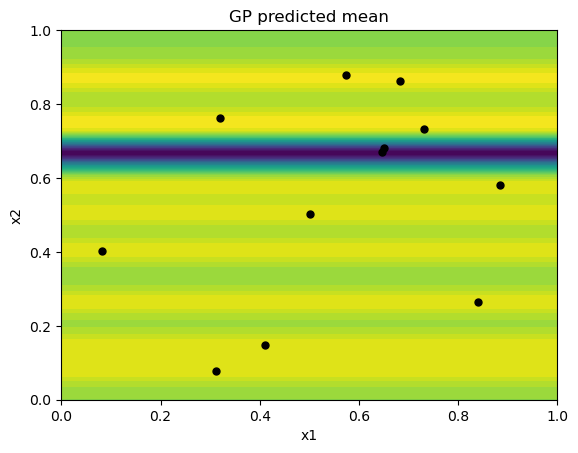

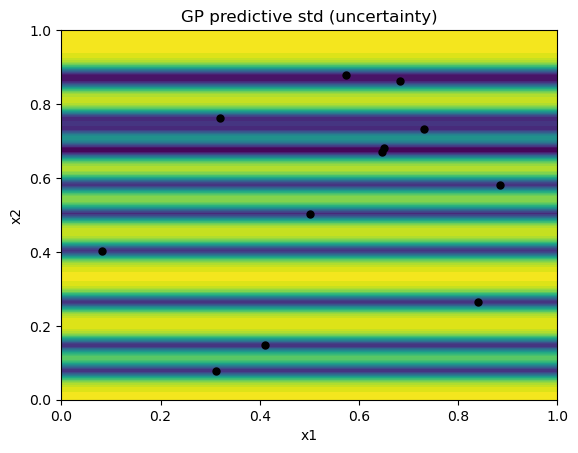

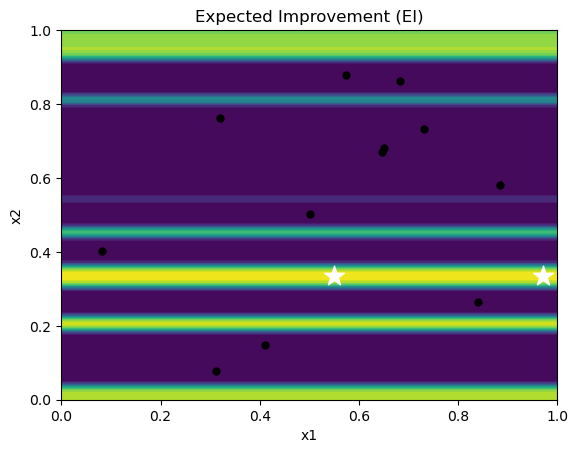


RF feature importances:
x1    0.515305
x2    0.484695
dtype: float64

Model comparison at proposed points:


,x1,x2,GP_mu,GP_sd,RF_mu,RF_sd,GBM_mu,GBM_sd
0,0.550173,0.334047,-0.000693,0.001605,-0.000277,0.000929,-0.000778,0.0
1,0.971901,0.334000,-0.000693,0.001605,-0.000552,0.001128,-0.000778,0.0


In [12]:
# ----------------------------
# 7) DIAGNOSTICS
# ----------------------------
# 7a) Predicted mean vs observed (training)
mu_train = gp.predict(X)
plt.figure()
plt.scatter(mu_train, y)
plt.xlabel("Predicted mean (GP) at observed X")
plt.ylabel("Observed y")
plt.title("Predicted vs Observed (training)")
plt.axline((0, 0), slope=1, linestyle="--")
plt.show()

# residuals
resid = y - mu_train
plt.figure()
plt.scatter(np.arange(len(resid)), resid)
plt.xlabel("Observation index")
plt.ylabel("Residual (y - pred)")
plt.title("Residuals on training data")
plt.axhline(0, linestyle="--")
plt.show()

# 7b) Are we stuck in one region? show observed points + suggested points
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Observed", alpha=0.85)
plt.scatter(X_next[:, 0], X_next[:, 1], marker="*", s=220, label="Next batch")
plt.xlim(BOUNDS[0]); plt.ylim(BOUNDS[1])
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Space coverage: observed + next batch")
plt.legend()
plt.show()

# 7c) Mean / Std / EI surfaces on a grid (for visibility)
def grid_eval(n=120):
    xs = np.linspace(BOUNDS[0, 0], BOUNDS[0, 1], n)
    ys = np.linspace(BOUNDS[1, 0], BOUNDS[1, 1], n)
    XX, YY = np.meshgrid(xs, ys)
    G = np.column_stack([XX.ravel(), YY.ravel()])
    mu, sd = gp.predict(G, return_std=True)
    ei_grid = expected_improvement(mu, sd, best_y, xi=XI, maximize=MAXIMIZE)
    return XX, YY, mu.reshape(n, n), sd.reshape(n, n), ei_grid.reshape(n, n)

XX, YY, MU, SD, EI = grid_eval()

plt.figure()
plt.contourf(XX, YY, MU, levels=30)
plt.scatter(X[:, 0], X[:, 1], c="k", s=25)
plt.title("GP predicted mean")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

plt.figure()
plt.contourf(XX, YY, SD, levels=30)
plt.scatter(X[:, 0], X[:, 1], c="k", s=25)
plt.title("GP predictive std (uncertainty)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

plt.figure()
plt.contourf(XX, YY, EI, levels=30)
plt.scatter(X[:, 0], X[:, 1], c="k", s=25)
plt.scatter(X_next[:, 0], X_next[:, 1], marker="*", s=220, c="w")
plt.title("Expected Improvement (EI)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

# 7d) Feature importances (RF baseline)
print("\nRF feature importances:")
print(pd.Series(rf.feature_importances_, index=["x1", "x2"]).sort_values(ascending=False))

# 7e) Compare model mean/std at proposed points (GP vs RF vs GBM)
mu_rf, sd_rf = rf_mean_std(rf, X_next)
mu_gb, sd_gb = gbm_mean_std(gbm_ens, X_next)

compare = submit_df.copy()
compare["GP_mu"] = gp.predict(X_next)
compare["GP_sd"] = gp.predict(X_next, return_std=True)[1]
compare["RF_mu"] = mu_rf
compare["RF_sd"] = sd_rf
compare["GBM_mu"] = mu_gb
compare["GBM_sd"] = sd_gb

print("\nModel comparison at proposed points:")
display(compare.round(6))



In [13]:
# ============================================================
# FINAL WEEK 03 SUBMISSION POINT (single X, highest uncertainty)
# ============================================================

final_X = compare.loc[compare["GP_sd"].idxmax(), ["x1", "x2"]]

print("\n=== FINAL WEEK 03 SUBMISSION (Function F1) ===")
print(f"x1 = {final_X['x1']:.6f}, x2 = {final_X['x2']:.6f}")



=== FINAL WEEK 03 SUBMISSION (Function F1) ===
x1 = 0.550173, x2 = 0.334047
